## Sparce representation...Graph representaion using matrix or 2D-array : We studed in Discrete Structures 

#### Sparce Graphs (Less no of Edges)     : not represented(implemented) using Sparce Representation
#### Dense  Graphs  (Greater no of Edges) : represented using Sparce Representation.

## Mostly the graphs are Sparce Graphs



## Graphs are mainly Implemented using Dictionaries. In python and other higher level languages.

### `defaultdict` -- A library for Implementing Graphs using dictionaries.It is used in practice.

#### We can converet undirected graphs into directed graphs: So we mainly study directed graphs only.(Weighted Directed Graphs) 

# ``Graphs - Traversal and Path Finding``

In [1]:
#just to draw graph.
import networkx as nx
import matplotlib.pyplot as plt

#for notebook
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
#just to draw graph.
def draw_graph_with_nx(G):
    pos = nx.spring_layout(G , iterations = 200)
    options = {"node_color" : 'white' , "alpha" : 1  , "node_size" : 2000 , "width" : 0.002,
               "font_size" : '25' , "edge_color" : 'brown' , "arrows" : True, 
              "arrowstyle" : 'Fancy,head_length = 1 , head_width = 1 , tail_width = 0.4'
    }

    labels = nx.get_node_attributes(G,"label")
    nx.draw(G,pos,labels = labels , **options)
    plt.show()

In [3]:
class DiGraph: #A graph is just a dictionary with keys as nodes and values as a list :
               #This list will have all the other nodes that have relation with key_node.
    
   
    def __init__(self):
        self.g = {}          #Graph is just a dictionary


    
    def add_node(self , node):
        #sainty check
        if node is self.g:                              #agr node self.g ma ha, yani ka koi `key` ha to wo already exist krti ha...
            raise ValueError("Node already in graph")

        self.g[node] = []                               #create a key in dictionary with `key==node` and a create a list as its value.   


    #to create relations between nodes inside the lists in `values`...
    def add_edge(self,src,dest):
        #sainty checks
        if src not in self.g:
            raise ValueError("Source not present!")
        if dest not in self.g:
            raise ValueError("Destination not present!")

        #nexts contain all the list elements(values) of a key.
        nexts = self.g[src]                                   #self.g[src] will return a `list` : (value) for that key(src)
        if dest in nexts:                                     #to form an egde is to simply add the node in the list against its key.
            return                                            #if dest alrady present in that list than just return

        nexts.append(dest)                                    #else append it in the list.





    #just to draw graph.
    def draw_graph(self):
        G = nx.DiGraph()
        for src in self.g:
            G.add_node(src,label = src)
            for dest in self.g[src]:
                G.add_edge(src,dest)
                
        draw_graph_with_nx(G)

In [4]:
g = DiGraph()

nodes  = ['a','b','c','d','e','f']

for n in nodes:
    g.add_node(n) #they will be added in the dictionary as the key : the values for all these keys are empty list [].

In [5]:
edges = [
    ('a','b'),
    ('a','c'),
    ('b','c'),
    ('b','d'),
    ('c','d'),
    ('d','c'),
    ('e','f'),
    ('f','c')
]
for e in edges:
    g.add_edge(e[0],e[1])

In [6]:
print(g.g) #print the dictionary(g) inside that diGraph(g).

{'a': ['b', 'c'], 'b': ['c', 'd'], 'c': ['d'], 'd': ['c'], 'e': ['f'], 'f': ['c']}


In [7]:
import pprint        #another library for printing the dictionary.
pprint.pprint(g.g)

{'a': ['b', 'c'],
 'b': ['c', 'd'],
 'c': ['d'],
 'd': ['c'],
 'e': ['f'],
 'f': ['c']}


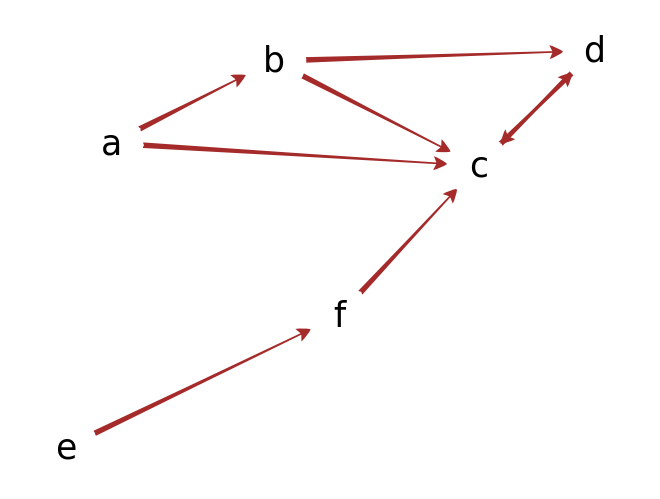

In [23]:
g.draw_graph()

# Traverse Graph

In [9]:
def traverse_graph(self,start):
    
    """Traverse graph from this `given` starting node: Starting node could be any node of graph"""
    """Its almost same as bredth first search (bfs) of trees: except the lines with word `visited`.This is because of loops in Graphs"""
   
    #we will use a queue to store the values and take them out from the first index.`pop(0)` 
    q = [start]                     
    
    #!!! #The visited concept is to save it from traversing again and again : save it from loop that are in graphs not in trees.
    visited = []

    while q:
        #first time start(first node) is present.
        current = q.pop(0)

        
        #if we've already visited it we can skip
        
        if current in visited: #!!!
            continue
            
        #whatever function we want to apply on that node 
        print(current)
        
        #we're done with this node.Keeping the track of nodes already visited.
        visited.append(current) #!!!

        #get all directly connected nodes
        next_nodes = self.g[current]


        #traverese all the nexts
        for n in next_nodes:
            q.append(n)



DiGraph.traverse_graph = traverse_graph

In [10]:
g.traverse_graph('a') #also traverse from 'e'

a
b
c
d


# Find Path

In [11]:
def find_path(self, start, end, path=[]): #path = [] , so we can also pass half path, than other half path will be calculated.
    """ Find a path (not necessarily shortest) from start to end recursively."""
    """ Only the `start` is changed in all recursive calls `end` remains same."""
    
    #sainty checks
    if start not in self.g:
        raise ValueError("Source node not in Graph")
    
    #save the path we have traveresed till now                              
    path = path + [start]                              #path.append(start)

    
    #base case!!!
    if start == end:
        return path
    
    
    #recursive case!!!
    for node in self.g[start]:                        
        
                                                        #needed to avoid cycles
        if node not in path:
                                                        #find path from next node to...
            newpath = self.find_path(node,end,path)     #recursion!!!
            if newpath:
                return newpath                          #if there is any path it will return from here.
            
                                                        #for both these if statements `else:continue` is present.
                                                        #if no path can be found from any of the next nodes to the end , there is no path!
    return None
DiGraph.find_path = find_path

In [12]:
g.find_path('a','d')

['a', 'b', 'c', 'd']

In [13]:
(g.find_path('a','f'))

In [14]:
g.find_path('a','a')

['a']

In [15]:
g.find_path('a','c')

['a', 'b', 'c']

# Find All Paths Instead

In [16]:
def find_all_paths(self, start, end, path=[]): #same to find_path with few changes. 
    

    
    if start not in self.g:
        raise ValueError("Source node not in Graph")
    
        
    path = path + [start]                              

    
    
    if start == end:
        return [path]   #change!!! This time there is a list of all paths
    

    all_paths = []     #change!!!
    
    for node in self.g[start]:                        
        
                                                       
        if node not in path:
            #changes!!!                                   
            all_newpaths = self.find_all_paths(node,end,path)    
            for newpath in all_newpaths:   #loop through all of them after recursion!!!
                all_paths.append(newpath)  # no return here!                     

    #!!!
    return all_paths


DiGraph.find_all_paths = find_all_paths

In [17]:
g.find_all_paths('a','d')

[['a', 'b', 'c', 'd'], ['a', 'b', 'd'], ['a', 'c', 'd']]

# Shortest Path

In [18]:
def find_shortest_path(self, start, end, path=[]): #same to find_path and find_all_paths with few changes
    

    
    if start not in self.g:
        raise ValueError("Source node not in Graph")
    
        
    path = path + [start]                              

    
    
    if start == end:
        return path                            #same because we will return only one path

    
    #change!!!
    shortest = None 

    
    for node in self.g[start]:                        
        
                                                       
        if node not in path:
                                                      
            newpath = self.find_shortest_path(node,end,path)    
            if newpath:  #change!!! instead of none find shortest.               
                if shortest is None or len(newpath) < len(shortest):     
                    shortest = newpath
                                                      
    
    #change!!! return shortest at end!!!
    return shortest


DiGraph.find_shortest_path = find_shortest_path

In [19]:
g.find_shortest_path('a','d')

['a', 'b', 'd']